### Clustering

- I need to do some clustering algos and see which does best
- Select which columns to use


What am I hoping clustering will do?
- Make more "like" groupings of school districts based on certain demographic data. 
- I believe the clusters will still have normal distribution curves, and linear relationships.

What columns are allowed in clustering -- For this one I want to make two selection types, one with ethnic data and one without as some grants or other funding does not like considering that information when benchmarking
- Eco-dis %
- student body size
- average teacher pay
- Ethnic homogeneity with students and staff
- Staff size


What makes up a row?
- a row will be made up of one school with all of its given metrics
- I want to only select schools who's metrics have not drastically changed in the past 3 years. What is why I have the historical data as I believe if a school has hd drastic changes they will be an outlier and throw off the model. for the school years data I will want to use the 2024 numbers as I believe any miss calculations have been adjusted by then (not sure if they even upload corrections but don't feel like looking as of now).
- I will need to normalize all the numbers down to aq 0 to 1 scale so large differences aren't causing issues.

I would also like to run an algo to see how strongly any one variable seems to be in relation to the overall outcomes

Right now, my data probably looks like a few loosely clouds semi clustered and overlapping because nothing is normalized and teacher pay of $40,000 and eco-dis count of 270 out of 3000 students are working together to make the a shape but are working on completely different scales, so I need an approach that with a very loss clustering algo until I clean further.

In [65]:
# Importing libraries
import pandas as pd
import numpy as np
import sklearn
from scipy import stats
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns


In [66]:
# loading in data sets
student_df = pd.read_csv(r"Clean Datasets\student_analysis_df.csv", dtype={'YearDistrict ID': str, 'DISTRICT': str, 'Year': str})
staff_df = pd.read_csv(r"Clean Datasets\staff_analysis_df.csv", dtype={'YearDistrict ID': str, 'DISTRICT': str, 'Year': str})


## Exploratory Clustering

- create two groupings og teachers
- Z-Score normalize
- 

- Stretch goal: Principal Components Analysis (PAC) on eco-dis, homeless


# Note something to consider is grouping teachers experience level

In [67]:
# Defining columns to keep

Id_col = ['YearDistrict ID', 'DISTRICT', 'Year']


student_col_to_keep = ['YearDistrict ID', 'DISTRICT', 'Year', 'All Students Count', 'Special Ed Count',
                        'Bilingual/ESL Count', 'Career & Technical Education Count',
                        'Gifted & Talented Count', 'EB/EL Count', 'Econ Disadv Count',
                        'Non-Educationally Disadv Count', 'At Risk Count',
                        'American Indian Count', 'Asian Count', 'Pacific Islander Count',
                        'Two or More Races Count', 'African American Count', 'Hispanic Count',
                        'White Count', 'Male Count', 'Female Count',
                        'Section 504 Count', 'Title I Count', 'Homeless Count',
                        'Immigrant Count', 'Migrant Count',
                        'Total Students with Disabilities Count',
                        'Intellectual Disabilities Count', 'Physical Disabilities Count',
                        'Behavioral Disabilities Count', 'District Name', 'County ID',
                        'County Name', 'Region', 'Charter Flag', 'DFLALTED']

staff_col_to_keep = [   'YearDistrict ID', 'Year', 'DISTRICT',       
                        'Teacher Total Full Time Equiv Count',
                        'Support Total Full Time Equiv Count',
                        'School Admin Total Full Time Equiv Count',
                        'Central Admin Total Full Time Equiv Count',
                        'Educ Aide Total Full Time Equiv Count',
                        'Teacher Total Base Salary Total', 'Support Total Base Salary Total',
                        'School Admin Total Base Salary Total',
                        'Teacher Beginning Full Time Equiv Count',
                        'Teacher 1-5 Years Full Time Equiv Count',
                        'Teacher 6-10 Years Full Time Equiv Count',
                        'Teacher 11-20 Years Full Time Equiv Count',
                        'Teacher 21-30 Years Full Time Equiv Count',
                        'Teacher > 30 Years Full Time Equiv Count',
                        'Teacher Beginning Base Salary Total',
                        'Teacher 1-5 Years Base Salary Total',
                        'Teacher 6-10 Years Base Salary Total',
                        'Teacher 11-20 Years Base Salary Total',
                        'Teacher 21-30 Years Base Salary Total',
                        'Teacher > 30 Years Base Salary Total',
                        'Teacher No Degree Full Time Equiv Count',
                        'Teacher BA Degree Full Time Equiv Count',
                        'Teacher MS Degree Full Time Equiv Count',
                        'Teacher PH Degree Full Time Equiv Count',
                        'Teacher American Indian Full Time Equiv Count',
                        'Teacher Pacific Islander Full Time Equiv Count',
                        'Teacher Asian Full Time Equiv Count',
                        'Teacher African American Full Time Equiv Count',
                        'Teacher Hispanic Full Time Equiv Count',
                        'Teacher White Full Time Equiv Count',
                        'Teacher Two or more races Full Time Equiv Count',
                        'Teacher Male Full Time Equiv Count',
                        'Teacher Female Full Time Equiv Count',
                        'Teacher Regular Program Full Time Equiv Count',
                        'Teacher Career & Technical Prgms Full Time Equiv Count',
                        'Teacher Bilingual Program Full Time Equiv Count',
                        'Teacher Compensatory Program Full Time Equiv Count',
                        'Teacher Gifted & Talented Program Full Time Equiv Count',
                        'Teacher Special Education Full Time Equiv Count',
                        'Teacher Other Full Time Equiv Count', 'Teacher Turnover Numerator',
                        'Teacher Turnover Denominator', 'Principal Experience Total',
                        'Principal Tenure Total', 'Assistant Principal Experience Total',
                        'Assistant Principal Tenure Total',
                        'Teacher Incentive Allotment Master Head Count',
                        'Teacher Incentive Allotment Exemplary Head Count',
                        'Teacher Incentive Allotment Recognized Head Count']

In [68]:
# FILTER: filtering data frames down to columns defined to keep
student_df = student_df[student_col_to_keep]
staff_df = staff_df[staff_col_to_keep]


### Beta-Binomial Model - Smoothed Rate Function (Explore shrinkage estimation and  smoothing tequinices)

Beta-Binomial shrinkage

Notes: A discovery happened as I was exploring my data sets post z-score calculations, and that was that some districts were in the range of (10, 9), but when I just open the data set, it looks like most of the numbers are in the range (1, -1). While I did not clearly know why, from what I have learned so far about statistical modeling, I could tell such huge ranges did not make sense, so I looked at the affected columns.

When I started exploring the affected columns, I noticed that often the cell that I calculated off of for example, the number of teachers with 30+ years of experience it may have been zero because it was a small district. Initially, I wanted to keep the data set whole. But I knew I could not just make the values NaN, as that would affect downstream statistical values by either creating them inaccurately or removing them from the data set. I wanted to try and keep as many rows or values as possible, because otherwise, I'd have to remove them from multiple years, and that would eventually shrink my data set to what I believe will be unusable because I'm only working within a thousand or so data points.

In school districts with small populations, even a single data point can create an extreme outlier. For example, in a district of only five teachers, one teacher constitutes 20% of the total; that would likely create a huge statistical anomaly in my calculations down the line. To prevent these small-population "flukes" from distorting our model, we apply a smoothing technique. This approach provides "statistical help" to smaller districts by pulling their rates toward the state average, ensuring that their limited data size doesn't create misleading extremes that skew the overall analysis.
 

In [69]:
# FUNCTION: Beta binomial shrinkage/smoothing

def bbm_smoothing(df, trials, successes, fake_trials=100):
    """
    This is a beta-binomial smoothing model, which is a more sophisticated way of determining a rate. 
    In situations with small sample sizes like a school district with only 10 teachers the small headcount 
    means theres a lower probability of seeing someone with 30-plus years of experience. Conversely, if a 
    small district happens to have 3 teachers in that category, it creates an extreme percentage that is 
    statistically unlikely but possible. My goal is to support these smaller districts by smoothing those values, ensuring 
    they aren't penalized by extreme outliers when we group or benchmark them later on.

    df: DataFrame
    Trial: In this case, the labor market of teachers in a given year.
    Success: Teachers with 30+ years of experience.
    fake_trials: How much assistance we give schools when calculating the smoothed rate.
    """
    
    # If we are just smoothing one column we need to make it a list item for the function to handel it
    if isinstance(successes, str):
        success = [successes]

    # Compute the smoothed rate for each column we are looking at.
    for success in successes:
        df[success] = df[success].fillna(0)
        n_trials = df.groupby('Year')[trials].transform('sum')      # Total number of trials
        k_successes = df.groupby('Year')[success].transform('sum')  # Total number of events that meet our criteria
        probability = (k_successes / n_trials).fillna(0)            # Rate of successes to trials
        fake_successes = probability*fake_trials                    # Alpha number of added fake successes

        df[success+"_bbm_smoothed"] = (df[success] + fake_successes)/(df[trials].fillna(0) + fake_trials)

    
    return df


In [70]:
# FUNCTION: Euclidean Distance
def calculate_euclidean_distance(df, columns, grouping_col='Year', central_tendency='mean', output_name=None):
    """
    Compute the euclidean distance of various features to each other
    """
    if isinstance(columns, str):
        columns = [columns]

    df = df.copy()

    def compute_reference_vector(group):
        """
        This function finds the reference vector we use to see how distance our comparison point is to the reference.

        In my example i want to find the mean or average ethnicity of a student or staff from 
        """
        
        if central_tendency == 'median':
            return group[columns].median()
        else:
            return group[columns].mean()
        

    def euclidean_distance_from_reference(row, reference_vector):
        """
        looking at the a given row we collect all of our vectors we want to look at and compute the distance from the reference
         
        euclidean distance = sqrt(x)
        """

        comparison_vector = row[columns].values.astype(float)
        diff = comparison_vector - reference_vector.values.astype(float)
        return np.sqrt(np.sum(diff ** 2))
    
    distance = []

    # We will need to make a if statement 
    for grouping_value, group in df.groupby(grouping_col):
        ref_vector = compute_reference_vector(group)

        group_distance = group.apply(
            lambda row: euclidean_distance_from_reference(row, ref_vector),
            axis=1
        )

        distance.append(group_distance)

        output_col_name = f"{output_name}_euclidean_distance"

        df[output_col_name] = pd.concat(distance).reindex(df.index)
    
    return df

In [71]:
# Function Herfindahl-Hirschman Index (HHI) - Measures how dominant any one group in in a market
def calculate_hhi(df, columns, output_col_name=None):
    """
    computes the Herfindahl-Hirschman Index (HHI) of a column, used only on columns who are with in a grouping whos sum equals 1
    for example ethnicity distribution. where the distribution is part of the whole "market"

    HHI formula is the sum of all the squared groups within the "market"

    HHI=0.3^2 + 0.1^2 + 0.6^2
    
    0.3, 0.1, 0.6 = the market share percentage of a group (for this example students and teachers ethnicity)
    """
    if isinstance(columns, str):
        columns = [columns]

    df = df.copy()

    values = df[columns]

    hhi = (values ** 2).sum(axis=1)
    output_name = f"{output_col_name}_hhi"
    df[output_name] = hhi

    return df

In [72]:
# FUNCTION: Calculating z score
def zscore(df: pd.DataFrame, columns):
    """
    Calculates the z score of a column grouped by year
    df: DataFrame
    """
    if isinstance(columns, str):
        columns = [columns]
        
    for col in columns:
        z_col = col+"_ZScore"
        df[z_col] = (
            df[col] -
            df.groupby('Year')[col].transform('mean')
        ) / df.groupby('Year')[col].transform('std')

    return df

In [73]:
# FUNCTION: Pay imputation problem for districts without a pay range

def imputing_pay(df):
    """
    The goal of this function is to impute (synthosize) the missing pay of the sample districts we bbm smoothed data for
    """
    pass

In [74]:
# FUNCTION: Find Weighted Mean and Variance for a group i.e. staff experience levels at a campus

def weighted_mean_variance(df, dict: dict, columns, output_col_name=None):
    """
    
    """
    
    if isinstance(columns, str):
        columns = [columns]

    weight_list = []
    for i in columns:
        # i.e. the bbm smoothed value is 0.9 * 1-5 years of experience mean makes it 2.5 * 0.9 = 2.25 I think....? not fully sure
        weighted_value = df[i]*dict[i]
        weight_list.append(weighted_value)

    mean = sum(weight_list)

    weighted_std= []
    for i in columns:
        num = ((df[i]*dict[i]) - mean)**2
        weighted_std.append(num)
    
    variance = np.sqrt(sum(weighted_std)/len(weighted_std))


    weighed_mean_col_name = output_col_name+"_weighted_mean"
    weighed_std_col_name = output_col_name+"_weighted_variance"
    
    df[weighed_mean_col_name] = mean
    df[weighed_std_col_name] = variance

    return df

In [75]:
# Select Student columns to bbm smooth

student_bbm_col = [ 'Career & Technical Education Count', 'Gifted & Talented Count',
                    'EB/EL Count','Econ Disadv Count', 'Non-Educationally Disadv Count',
                    'At Risk Count', 'Male Count', 'Female Count','Homeless Count', 'Immigrant Count', 'Migrant Count',
                    'American Indian Count', 'Asian Count','Pacific Islander Count', 'Two or More Races Count',
                    'African American Count', 'Hispanic Count', 'White Count']

In [76]:
# Defining staff columns

                    # Teacher Experience Levels
teacher_bbm_col  =[ 'Teacher Beginning Full Time Equiv Count',
                    'Teacher 1-5 Years Full Time Equiv Count',
                    'Teacher 6-10 Years Full Time Equiv Count',
                    'Teacher 11-20 Years Full Time Equiv Count',
                    'Teacher 21-30 Years Full Time Equiv Count',
                    'Teacher > 30 Years Full Time Equiv Count',

                    # Teacher Education Levels
                    'Teacher No Degree Full Time Equiv Count',
                    'Teacher BA Degree Full Time Equiv Count',
                    'Teacher MS Degree Full Time Equiv Count',
                    'Teacher PH Degree Full Time Equiv Count',

                    # Teacher Ethnicity
                    'Teacher American Indian Full Time Equiv Count',
                    'Teacher Pacific Islander Full Time Equiv Count',
                    'Teacher Asian Full Time Equiv Count',
                    'Teacher African American Full Time Equiv Count',
                    'Teacher Hispanic Full Time Equiv Count',
                    'Teacher White Full Time Equiv Count',
                    'Teacher Two or more races Full Time Equiv Count']

                    # Teacher pay ranges
teacher_pay =      ['Teacher Beginning Base Salary Total',
                    'Teacher 1-5 Years Base Salary Total',
                    'Teacher 6-10 Years Base Salary Total',
                    'Teacher 11-20 Years Base Salary Total',
                    'Teacher 21-30 Years Base Salary Total',
                    'Teacher > 30 Years Base Salary Total']

In [77]:
# Smoothing Student and staff
student_df_1 = bbm_smoothing(student_df,'All Students Count', student_bbm_col) 

#staff_df_1.fillna(0, inplace=True)
staff_df_1 = bbm_smoothing(staff_df,'Teacher Total Full Time Equiv Count', teacher_bbm_col)

In [78]:
# Defining bbm smoothed columns to compute on
bbm_eth_student_col = [  'American Indian Count_bbm_smoothed', 'Asian Count_bbm_smoothed',
                     'Pacific Islander Count_bbm_smoothed',
                     'Two or More Races Count_bbm_smoothed',
                     'African American Count_bbm_smoothed', 'Hispanic Count_bbm_smoothed',
                     'White Count_bbm_smoothed']

bbm_eth_staff_col = ['Teacher American Indian Full Time Equiv Count',
                    'Teacher Pacific Islander Full Time Equiv Count',
                    'Teacher Asian Full Time Equiv Count',
                    'Teacher African American Full Time Equiv Count',
                    'Teacher Hispanic Full Time Equiv Count',
                    'Teacher White Full Time Equiv Count',
                    'Teacher Two or more races Full Time Equiv Count']

In [79]:
student_df_1 = calculate_hhi(student_df_1, bbm_eth_student_col, "student_ethnicity")
student_df_1 = calculate_euclidean_distance(student_df_1, bbm_eth_student_col, output_name='student_ethnicity')

In [80]:
student_zscore =['student_ethnicity_euclidean_distance','At Risk Count_bbm_smoothed','Econ Disadv Count_bbm_smoothed']

In [81]:
student_df_1 = zscore(student_df_1, student_zscore)

In [82]:
student_df_1.columns
#staff_df_1.columns

Index(['YearDistrict ID', 'DISTRICT', 'Year', 'All Students Count',
       'Special Ed Count', 'Bilingual/ESL Count',
       'Career & Technical Education Count', 'Gifted & Talented Count',
       'EB/EL Count', 'Econ Disadv Count', 'Non-Educationally Disadv Count',
       'At Risk Count', 'American Indian Count', 'Asian Count',
       'Pacific Islander Count', 'Two or More Races Count',
       'African American Count', 'Hispanic Count', 'White Count', 'Male Count',
       'Female Count', 'Section 504 Count', 'Title I Count', 'Homeless Count',
       'Immigrant Count', 'Migrant Count',
       'Total Students with Disabilities Count',
       'Intellectual Disabilities Count', 'Physical Disabilities Count',
       'Behavioral Disabilities Count', 'District Name', 'County ID',
       'County Name', 'Region', 'Charter Flag', 'DFLALTED',
       'Career & Technical Education Count_bbm_smoothed',
       'Gifted & Talented Count_bbm_smoothed', 'EB/EL Count_bbm_smoothed',
       'Econ Disadv Co

### Exploring data shape

This next section is exploring data shapes. It’s a way for me to more intuitively understand what I'm working with and see potential relationships hidden within the data. It's also for confirming some of my beliefs, or making me readjust what I’m going to move forward with regarding certain data points.

In [83]:
student_24 = student_df_1[student_df_1['Year']=='2024']

In [84]:
staff_experiecne_dict = {
       'Teacher Beginning Full Time Equiv Count_bbm_smoothed':1,
       'Teacher 1-5 Years Full Time Equiv Count_bbm_smoothed':2.5,
       'Teacher 6-10 Years Full Time Equiv Count_bbm_smoothed': 8.5,
       'Teacher 11-20 Years Full Time Equiv Count_bbm_smoothed': 15,
       'Teacher 21-30 Years Full Time Equiv Count_bbm_smoothed': 25,
       'Teacher > 30 Years Full Time Equiv Count_bbm_smoothed': 30
}

staff_experiecne_col_list = [
       'Teacher Beginning Full Time Equiv Count_bbm_smoothed',
       'Teacher 1-5 Years Full Time Equiv Count_bbm_smoothed',
       'Teacher 6-10 Years Full Time Equiv Count_bbm_smoothed',
       'Teacher 11-20 Years Full Time Equiv Count_bbm_smoothed',
       'Teacher 21-30 Years Full Time Equiv Count_bbm_smoothed',
       'Teacher > 30 Years Full Time Equiv Count_bbm_smoothed']

In [85]:
#staff_df_1.columns

,YearDistrict ID,Year,DISTRICT,Teacher Total Full Time Equiv Count,Support Total Full Time Equiv Count,School Admin Total Full Time Equiv Count,Central Admin Total Full Time Equiv Count,Educ Aide Total Full Time Equiv Count,Teacher Total Base Salary Total,Support Total Base Salary Total,...,Teacher PH Degree Full Time Equiv Count_bbm_smoothed,Teacher American Indian Full Time Equiv Count_bbm_smoothed,Teacher Pacific Islander Full Time Equiv Count_bbm_smoothed,Teacher Asian Full Time Equiv Count_bbm_smoothed,Teacher African American Full Time Equiv Count_bbm_smoothed,Teacher Hispanic Full Time Equiv Count_bbm_smoothed,Teacher White Full Time Equiv Count_bbm_smoothed,Teacher Two or more races Full Time Equiv Count_bbm_smoothed,Teacher_Expereiance_weighted_mean,Teacher_Expereiance_weighted_variance
0,2017001902,2017,001902,52.4,6.9,4.1,2.5,13.5,2418873.4,350003.3,...,0.004167,0.002303,0.002847,0.009840,0.079201,0.181011,0.717565,0.007235,6.884361,5.979546
1,2017001903,2017,001903,103.0,7.0,6.0,2.0,26.8,4628074.1,346087.0,...,0.003128,0.001729,0.002137,0.007387,0.059459,0.155597,0.768260,0.005432,7.707767,6.729535
2,2017001904,2017,001904,59.0,5.0,4.0,3.0,19.9,2580639.3,276976.0,...,0.003994,0.002208,0.002729,0.009431,0.088492,0.173498,0.710420,0.013224,6.523124,5.636129
3,2017001906,2017,001906,35.3,2.0,3.0,5.0,7.0,1548155.4,90675.0,...,0.004694,0.002594,0.003207,0.011083,0.089211,0.196497,0.689260,0.008150,7.043434,6.099911
4,2017001907,2017,001907,263.5,28.0,17.0,8.0,74.2,11827846.6,1459280.2,...,0.001747,0.003717,0.003945,0.004125,0.095929,0.143291,0.734957,0.014038,5.875589,5.044567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10327,2025252902,2025,252902,24.8,0.7,2.0,1.0,10.2,1479470.0,49629.0,...,0.006582,0.002672,0.001014,0.017391,0.101477,0.264443,0.602563,0.010447,11.779403,9.953872
10328,2025252903,2025,252903,73.3,7.7,6.3,1.0,1.0,4098574.3,515342.9,...,0.004740,0.001924,0.000730,0.018294,0.084618,0.212363,0.675129,0.007524,11.448756,9.638681
10329,2025253901,2025,253901,240.2,47.4,14.3,11.0,62.7,13664248.8,3345159.2,...,0.005354,0.000980,0.000372,0.006380,0.037226,0.776609,0.171663,0.006772,11.102497,9.402133
10330,2025254901,2025,254901,107.8,22.9,13.2,7.0,62.8,6129788.5,1547240.3,...,0.003953,0.001605,0.000609,0.010444,0.065757,0.629464,0.285851,0.006275,10.890132,9.200206


R-squared: 0.4803


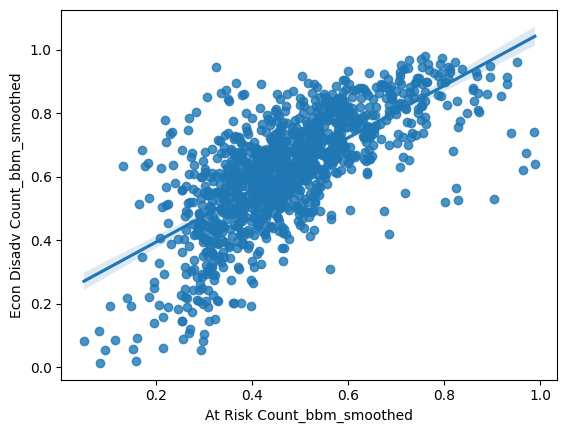

In [ ]:
sns.regplot(
    data=student_24,
    #x='student_ethnicity_hhi',
    x='At Risk Count_bbm_smoothed',
    y='Econ Disadv Count_bbm_smoothed',

    #y='student_ethnicity_euclidean_distance',
    #hue=pd.qcut(student_24['All Students Count'], q=6)
)

slope, intercept, r_value, p_value, std_err = stats.linregress(student_24['At Risk Count_bbm_smoothed'], student_24['Econ Disadv Count_bbm_smoothed'])
# High HHI = Homogeneous; Low HHI = Diverse\
print(f"R-squared: {r_value**2:.4f}")

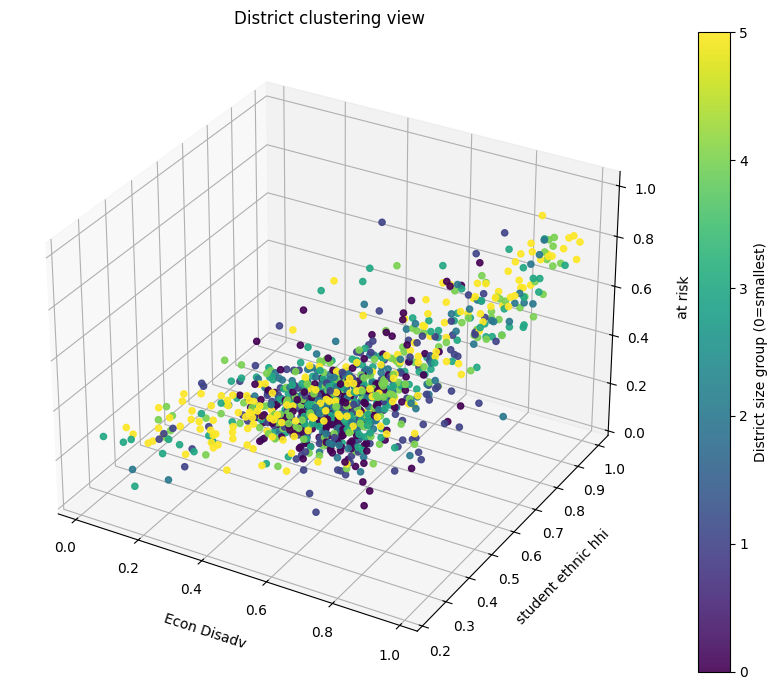

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

groups = pd.qcut(student_24['All Students Count'], q=6)

scatter = ax.scatter(
    #student_24['student_ethnicity_euclidean_distance'],
    student_24['Econ Disadv Count_bbm_smoothed'],
    student_24['student_ethnicity_hhi'],
    student_24['At Risk Count_bbm_smoothed'],

          

    c=groups.cat.codes,
    cmap='viridis',   
    alpha=0.9,        # slight transparency so overlapping points don't hide each other
    s=20              # smaller points, easier to see the shape of the cloud
)

ax.set_zlabel('at risk', labelpad=10)
ax.set_ylabel('student ethnic hhi', labelpad=10)
ax.set_xlabel('Econ Disadv', labelpad=10)
ax.set_title('District clustering view')

fig.colorbar(scatter, ax=ax, label='District size group (0=smallest)')

plt.tight_layout()
plt.show()

In [ ]:
groups = pd.qcut(student_24['All Students Count'], q=6)

# Pull out the three axes and normalize each to 0-1 range
# so the shape isn't stretched weirdly in 3D space
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

x = normalize(student_24['student_ethnicity_euclidean_distance']).values
y = normalize(student_24['student_ethnicity_hhi']).values
z = normalize(student_24['At Risk Count_bbm_smoothed']).values


# Map group codes to colors (viridis-ish: 6 groups, 6 colors)
# OBJ format supports vertex colors in some viewers
color_map = {
    0: (0.267, 0.005, 0.329),  # dark purple  (smallest districts)
    1: (0.283, 0.341, 0.620),  # blue
    2: (0.163, 0.576, 0.558),  # teal
    3: (0.134, 0.738, 0.450),  # green
    4: (0.578, 0.858, 0.140),  # yellow-green
    5: (0.993, 0.906, 0.144),  # yellow        (largest districts)
}

codes = groups.cat.codes.values

with open('districts_3d.obj', 'w') as f:
    f.write("# District clustering point cloud\n")
    f.write(f"# Points: {len(x)}\n")
    f.write("# Axes: X=Euclidean Distance, z=At Risk smoothed, y=Student HHI\n")
    f.write("# Color = district size group (dark=small, bright=large)\n\n")
    
    for i in range(len(x)):
        r, g, b = color_map[codes[i]]
        # 'v x y z r g b' is extended OBJ vertex format with color
        f.write(f"v {x[i]:.6f} {y[i]:.6f} {z[i]:.6f} {r:.3f} {g:.3f} {b:.3f}\n")

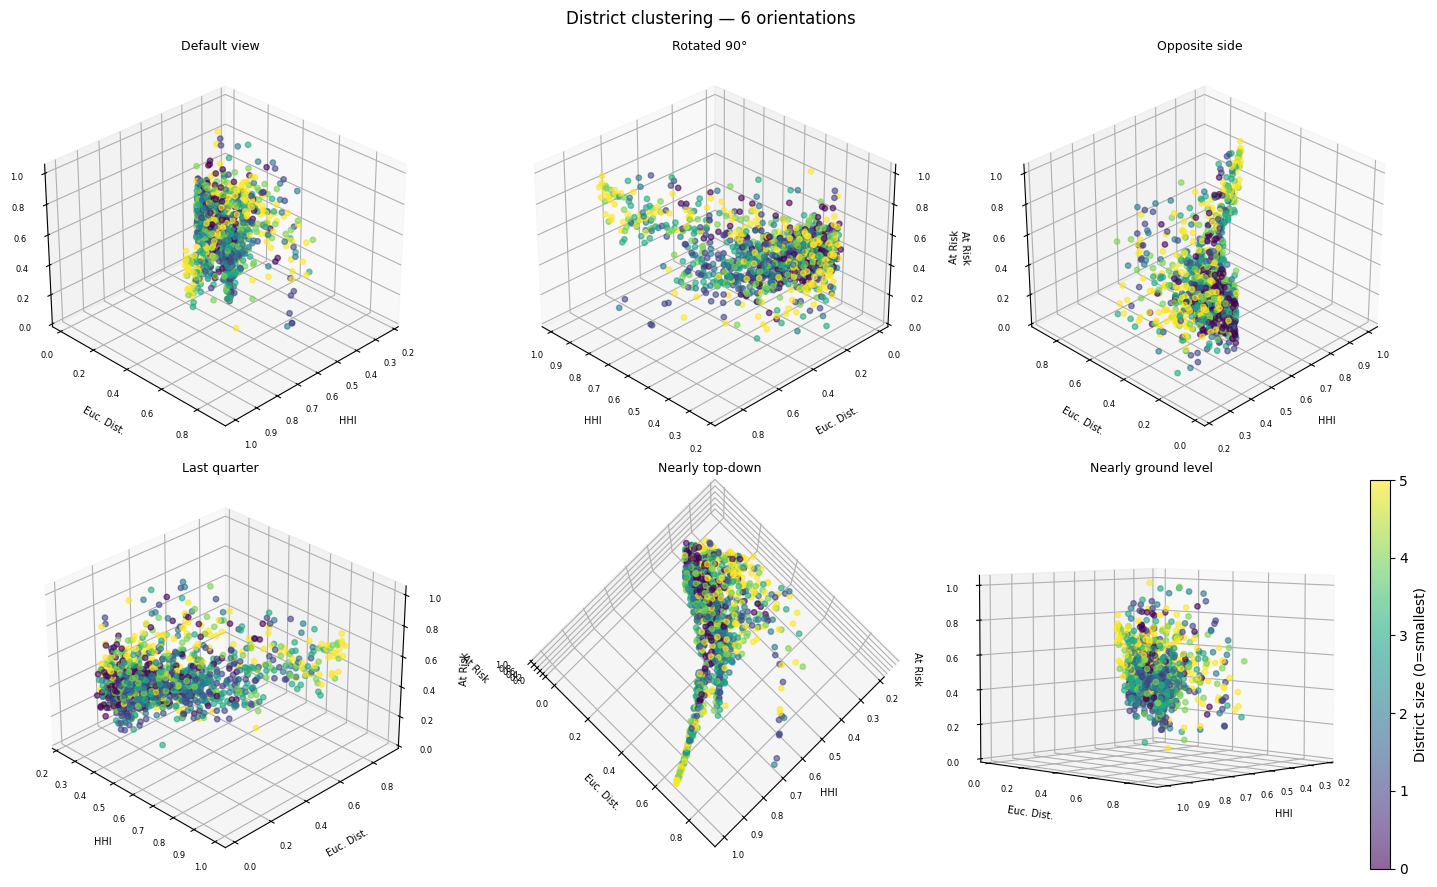

In [ ]:
groups = pd.qcut(student_24['All Students Count'], q=6)

# Define the views you want to see
views = [
    (30, 45,  'Default view'),
    (30, 135, 'Rotated 90°'),
    (30, 225, 'Opposite side'),
    (30, 315, 'Last quarter'),
    (85, 45,  'Nearly top-down'),
    (5,  45,  'Nearly ground level'),
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9),
    subplot_kw={'projection': '3d'}
)

for ax, (elev, azim, title) in zip(axes.flatten(), views):
    sc = ax.scatter(
   
        student_24['student_ethnicity_hhi'],
             student_24['student_ethnicity_euclidean_distance'],
                     student_24['At Risk Count_bbm_smoothed'],

        
       c=groups.cat.codes,
       cmap='viridis',
       alpha=0.6,
        s=15
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('HHI', fontsize=7, labelpad=5)
    ax.set_ylabel('Euc. Dist.', fontsize=7, labelpad=5)
    ax.set_zlabel('At Risk', fontsize=7, labelpad=5)
    ax.tick_params(labelsize=6)

fig.colorbar(sc, ax=axes.flatten()[-1], label='District size (0=smallest)')
plt.suptitle('District clustering — 6 orientations', fontsize=12)
plt.tight_layout()
plt.show()

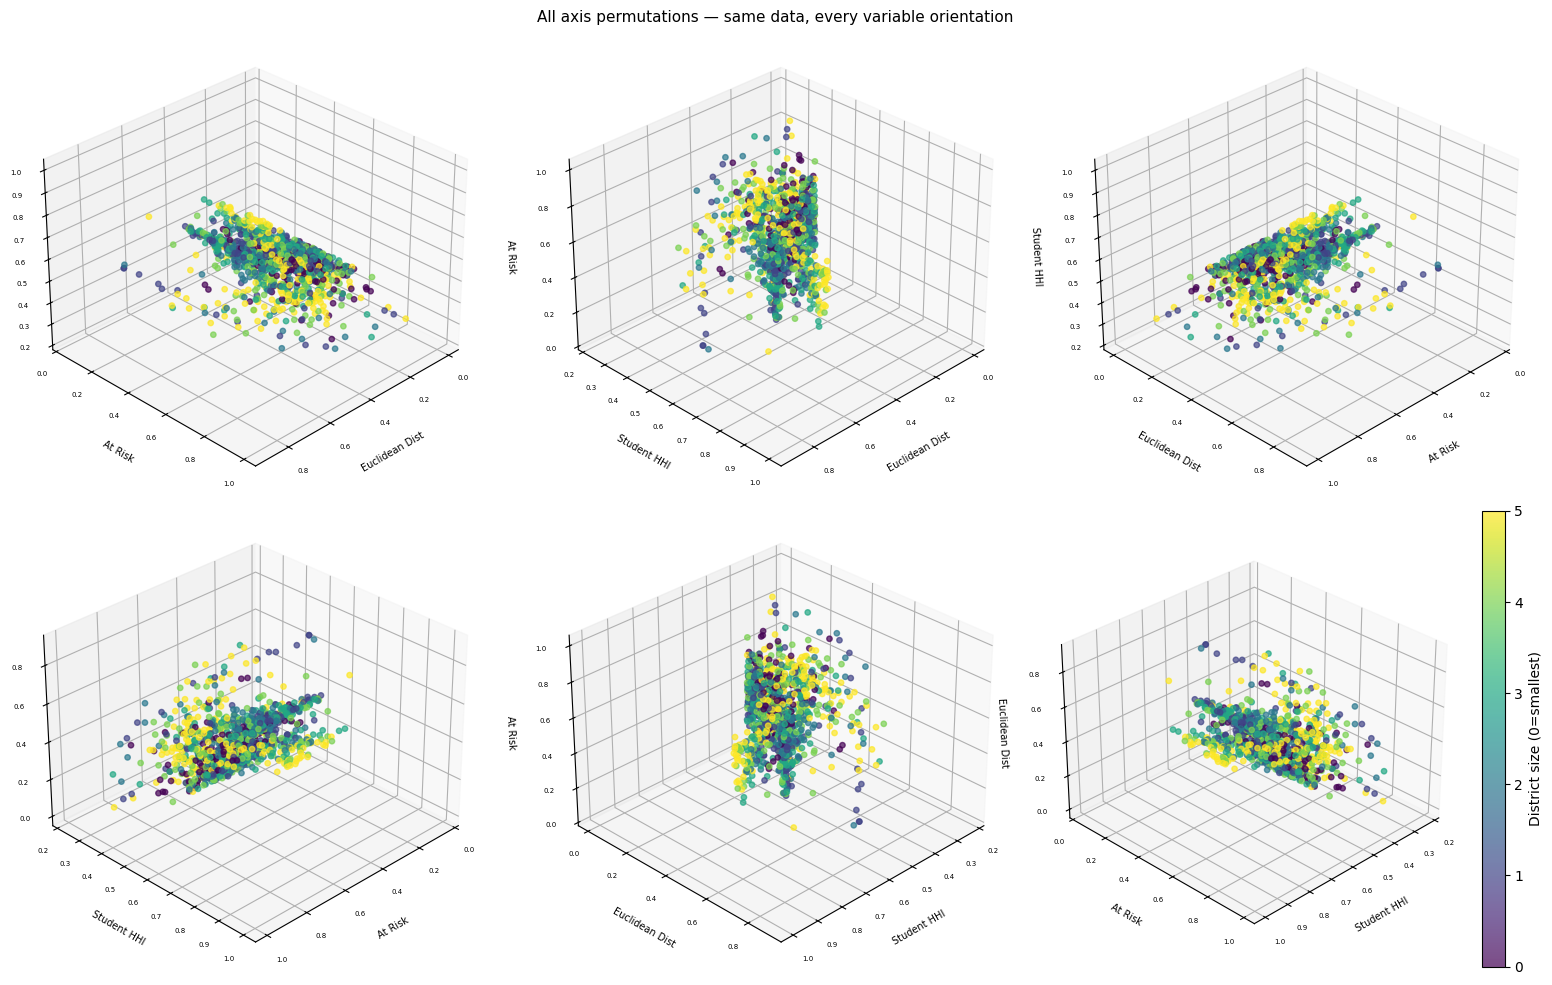

In [ ]:
import itertools

groups = pd.qcut(student_24['All Students Count'], q=6)

# Define your variables — add or remove from here as needed
variables = {
    'Euclidean Dist':  student_24['student_ethnicity_euclidean_distance'],
    'At Risk':         student_24['At Risk Count_bbm_smoothed'],
    'Student HHI':     student_24['student_ethnicity_hhi'],
}

# Get every unique combination of 3 variables assigned to X, Y, Z
# itertools.permutations gives you all orderings so you see every axis assignment
combos = list(itertools.permutations(variables.keys()))

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    subplot_kw={'projection': '3d'}
)

for ax, (xvar, yvar, zvar) in zip(axes.flatten(), combos):
    sc = ax.scatter(
        variables[xvar],
        variables[yvar],
        variables[zvar],
        c=groups.cat.codes,
        cmap='viridis',
        alpha=0.7,
        s=15
    )
    ax.view_init(elev=30, azim=45)
    ax.set_xlabel(xvar, fontsize=7, labelpad=5)
    ax.set_ylabel(yvar, fontsize=7, labelpad=5)
    ax.set_zlabel(zvar, fontsize=7, labelpad=5)
    ax.tick_params(labelsize=5)

fig.colorbar(sc, ax=axes.flatten()[-1], label='District size (0=smallest)')
plt.suptitle('All axis permutations — same data, every variable orientation', fontsize=11)
plt.tight_layout()
plt.show()

Thought: Okay, I actually just want you to clarify my thoughts into a single paragraph so I can remember it and read it. So don't, just write out a paragraph of what I'm saying, clearing it up. So we take the Texas mean, or median, or average, we'll figure it out, but it's one of those numbers that we're trying to find. And I actually just want it to be the mean, I think, if that's the average, because whatever the highest point of its standard distribution score would be. And I want to use that because that's equivalent to what's most standard across all of Texas. And then we'll compute the Euclidean distance from that perfect score, or from that perfect Texas equivalent. And then, and the reason I wanna do that is because when I, I'll now have a better zero to work with, as I'll call it. Or yeah, just a location to reference from how far you are. And maybe, and then I'm thinking, with that, now I can compute the furthest ones from certain distances. And now if I wanted to filter by different things, I could. And I'm thinking it would, yeah.

Chat Output: We define a baseline “reference distribution” for Texas by taking the mean proportion of each ethnicity across all schools (i.e., the average share of each group statewide), treating that as the most typical or standard composition. Each school’s ethnic distribution—optionally smoothed first for stability—is then represented as a vector of proportions and compared to this Texas baseline using Euclidean distance. This distance measures how far a school deviates from the state’s typical makeup, giving us a clear reference point (a “zero”) where a distance of 0 means the school mirrors Texas exactly, and larger values indicate increasing divergence. With this setup, we can rank schools by how representative they are, identify outliers that differ the most from the state norm, and flexibly filter or analyze schools based on how far they sit from that baseline.

I believe some of the most valuable indicators for this model will be socio-economic status (EcoDis), At-Risk percentages, teacher pay, and teacher experience. Among the variables I can control that are not related to ethnicity, these should yield the best results.

If I decide to include ethnic variables as well, I should evaluate ethnic distribution and teacher ethnic homogeneity, specifically using the Herfindahl-Hirschman Index (HHI) for student ethnicity. Additionally, I should analyze how closely those student distributions correlate with teacher demographics. Finally, I want to calculate the Euclidean distance of student ethnicity from the Texas state mean, as well as the Euclidean distance between the school's student ethnicity and the staff's ethnicity.

## Clustering Algorithms

DBSCAN - (Density-Based Spatial Clustering of Applications with Noise) 

1) student staff ethnic Euclidean distance
2) weighted mean staff experience
3) staff experience variance
4) Staff pay variance
5) weighted mean staff pay
6) eco-dis 
7) at risk

In [90]:
staff_df_1 = weighted_mean_variance(staff_df_1, staff_experiecne_dict,staff_experiecne_col_list, "Teacher_Expereiance" )

In [91]:
staff_df_1 = zscore(staff_df_1, ['Teacher_Expereiance_weighted_mean', 'Teacher_Expereiance_weighted_variance'])
staff_df_1

,YearDistrict ID,Year,DISTRICT,Teacher Total Full Time Equiv Count,Support Total Full Time Equiv Count,School Admin Total Full Time Equiv Count,Central Admin Total Full Time Equiv Count,Educ Aide Total Full Time Equiv Count,Teacher Total Base Salary Total,Support Total Base Salary Total,...,Teacher Pacific Islander Full Time Equiv Count_bbm_smoothed,Teacher Asian Full Time Equiv Count_bbm_smoothed,Teacher African American Full Time Equiv Count_bbm_smoothed,Teacher Hispanic Full Time Equiv Count_bbm_smoothed,Teacher White Full Time Equiv Count_bbm_smoothed,Teacher Two or more races Full Time Equiv Count_bbm_smoothed,Teacher_Expereiance_weighted_mean,Teacher_Expereiance_weighted_variance,Teacher_Expereiance_weighted_mean_ZScore,Teacher_Expereiance_weighted_variance_ZScore
0,2017001902,2017,001902,52.4,6.9,4.1,2.5,13.5,2418873.4,350003.3,...,0.002847,0.009840,0.079201,0.181011,0.717565,0.007235,6.884361,5.979546,0.434549,0.486166
1,2017001903,2017,001903,103.0,7.0,6.0,2.0,26.8,4628074.1,346087.0,...,0.002137,0.007387,0.059459,0.155597,0.768260,0.005432,7.707767,6.729535,1.870672,1.947627
2,2017001904,2017,001904,59.0,5.0,4.0,3.0,19.9,2580639.3,276976.0,...,0.002729,0.009431,0.088492,0.173498,0.710420,0.013224,6.523124,5.636129,-0.195495,-0.183033
3,2017001906,2017,001906,35.3,2.0,3.0,5.0,7.0,1548155.4,90675.0,...,0.003207,0.011083,0.089211,0.196497,0.689260,0.008150,7.043434,6.099911,0.711992,0.720713
4,2017001907,2017,001907,263.5,28.0,17.0,8.0,74.2,11827846.6,1459280.2,...,0.003945,0.004125,0.095929,0.143291,0.734957,0.014038,5.875589,5.044567,-1.324876,-1.335777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10327,2025252902,2025,252902,24.8,0.7,2.0,1.0,10.2,1479470.0,49629.0,...,0.001014,0.017391,0.101477,0.264443,0.602563,0.010447,11.779403,9.953872,0.440259,0.441518
10328,2025252903,2025,252903,73.3,7.7,6.3,1.0,1.0,4098574.3,515342.9,...,0.000730,0.018294,0.084618,0.212363,0.675129,0.007524,11.448756,9.638681,0.169505,0.138904
10329,2025253901,2025,253901,240.2,47.4,14.3,11.0,62.7,13664248.8,3345159.2,...,0.000372,0.006380,0.037226,0.776609,0.171663,0.006772,11.102497,9.402133,-0.114033,-0.088204
10330,2025254901,2025,254901,107.8,22.9,13.2,7.0,62.8,6129788.5,1547240.3,...,0.000609,0.010444,0.065757,0.629464,0.285851,0.006275,10.890132,9.200206,-0.287930,-0.282075


In [92]:
clustering_df = pd.merge(student_df_1, staff_df_1, on="YearDistrict ID")
clustering_df = clustering_df[clustering_df['Year_x']=='2024']
clustering_df = clustering_df[['YearDistrict ID', 'DISTRICT_x', 'Year_x','student_ethnicity_euclidean_distance_ZScore','At Risk Count_bbm_smoothed_ZScore','Econ Disadv Count_bbm_smoothed_ZScore', 'Teacher_Expereiance_weighted_mean_ZScore', 'Teacher_Expereiance_weighted_variance_ZScore']].reset_index(drop=True)

In [123]:
slope, intercept, r_value, p_value, std_err = stats.linregress(clustering_df['Teacher_Expereiance_weighted_variance_ZScore'], clustering_df['Teacher_Expereiance_weighted_mean_ZScore'])
# High HHI = Homogeneous; Low HHI = Diverse\
print(f"R-squared: {r_value**2:.4f}")

R-squared: 0.9997


In [93]:
clustering_df

,YearDistrict ID,DISTRICT_x,Year_x,student_ethnicity_euclidean_distance_ZScore,At Risk Count_bbm_smoothed_ZScore,Econ Disadv Count_bbm_smoothed_ZScore,Teacher_Expereiance_weighted_mean_ZScore,Teacher_Expereiance_weighted_variance_ZScore
0,2024001902,001902,2024,0.765078,-0.232676,-0.550227,1.156409,1.153603
1,2024001903,001903,2024,0.942474,-1.021566,-0.174570,0.883782,0.874904
2,2024001904,001904,2024,0.656926,-0.705576,-0.464524,0.074652,0.058908
3,2024001906,001906,2024,0.136518,-0.647163,-0.535985,-0.005898,-0.014121
4,2024001907,001907,2024,-0.632590,0.317710,1.075101,0.625607,0.602688
...,...,...,...,...,...,...,...,...
1143,2024252902,252902,2024,-0.095410,-0.611308,-0.661080,0.624465,0.618275
1144,2024252903,252903,2024,-0.945253,-0.187289,0.150137,-0.120386,-0.133653
1145,2024253901,253901,2024,2.139115,0.681849,1.497085,0.228750,0.238892
1146,2024254901,254901,2024,1.973914,-0.144374,1.092321,-0.445609,-0.438101


<Axes: xlabel='At Risk Count_bbm_smoothed_ZScore', ylabel='Teacher_Expereiance_weighted_mean_ZScore'>

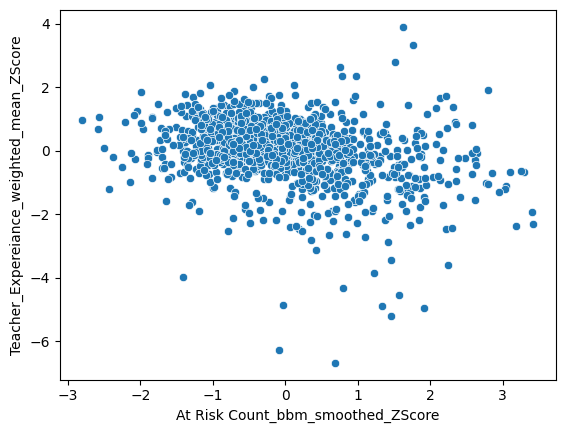

In [163]:
sns.scatterplot(
    data=clustering_df,
    #x='student_ethnicity_hhi',
    x='At Risk Count_bbm_smoothed_ZScore',
    y='Teacher_Expereiance_weighted_mean_ZScore',

    #y='student_ethnicity_euclidean_distance',
    #hue=pd.qcut(student_24['All Students Count'], q=6)
)

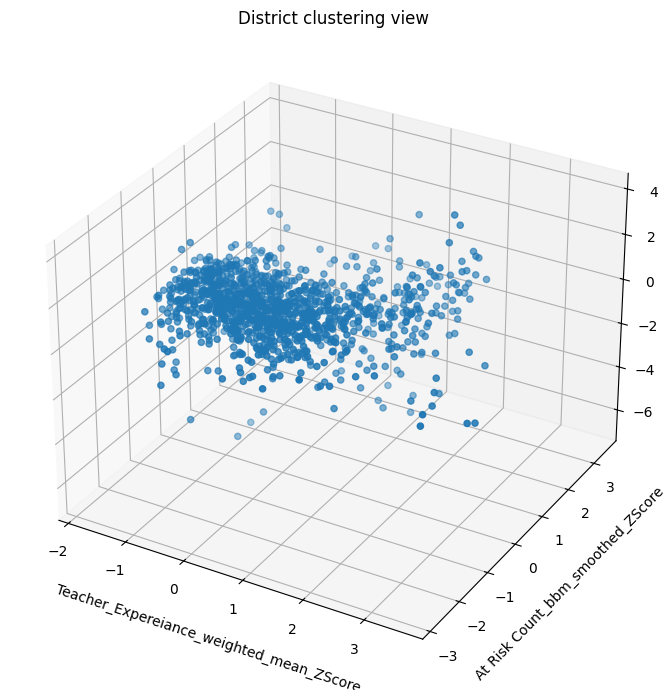

In [178]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

y= 'At Risk Count_bbm_smoothed_ZScore'
z = 'Teacher_Expereiance_weighted_mean_ZScore'
x = 'student_ethnicity_euclidean_distance_ZScore'

scatter = ax.scatter(
    #student_24['student_ethnicity_euclidean_distance'],
    clustering_df[x],
    clustering_df[y],
    clustering_df[z],
)

ax.set_zlabel(z, labelpad=10)
ax.set_ylabel(y, labelpad=10)
ax.set_xlabel(z, labelpad=10)
ax.set_title('District clustering view')

plt.tight_layout()
plt.show()

In [124]:
# Defining nearest neighbors to get
neigh = sklearn.neighbors.NearestNeighbors(n_neighbors=6, radius=0.8)
neigh.fit(clustering_df[['At Risk Count_bbm_smoothed_ZScore','Econ Disadv Count_bbm_smoothed_ZScore', 'Teacher_Expereiance_weighted_mean_ZScore']])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",0.8
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [167]:
eps = 0.3
min_samples = 6
dbscan = sklearn.cluster.DBSCAN(eps=eps, min_samples=min_samples)
# clustering_labels = dbscan.fit_predict(clustering_df[['At Risk Count_bbm_smoothed_ZScore','Econ Disadv Count_bbm_smoothed_ZScore', 'Teacher_Expereiance_weighted_mean_ZScore', 'Teacher_Expereiance_weighted_variance_ZScore']])
# clustering_labels = dbscan.fit_predict(clustering_df[['At Risk Count_bbm_smoothed_ZScore','Econ Disadv Count_bbm_smoothed_ZScore', 'Teacher_Expereiance_weighted_mean_ZScore']])
clustering_labels = dbscan.fit_predict(clustering_df[['At Risk Count_bbm_smoothed_ZScore', 'Teacher_Expereiance_weighted_mean_ZScore', 'student_ethnicity_euclidean_distance_ZScore']])

In [168]:
clustering_df['labels'] = clustering_labels

In [169]:
lables = clustering_df[['labels']]
lables

,labels
0,-1
1,0
2,0
3,0
4,0
...,...
1143,0
1144,0
1145,-1
1146,-1


In [ ]:
# Clean each ethnic group's raw proportions using beta-binomial smoothing to stabilize small sample sizes

# Compute the mean of each ethnic group's smoothed proportions across all Texas districts

# Store those means as a single vector this is our "Texas reference distribution" (the perfectly typical Texas school)

# Compute the Euclidean distance between each district's smoothed proportion vector and the Texas reference vector

# Identify the district with the largest Euclidean distance from the reference vector this becomes our d_max

# Normalize each district's distance by d_max, then subtract from 1 to produce a 0–1 representativeness score
